# Recitation 0.16 : DataLoaders

This notebook builds on the Dataset recitation to cover the PyTorch **`DataLoader`** end to end: how it turns a `Dataset` into shuffled, batched, efficiently-loaded data. We will cover some important settings that we will work with during our homeworks.

PyTorch Reference: https://pytorch.org/docs/stable/data.html

# Contents

1. The `Dataset` / `DataLoader` split
2. A custom `Dataset` (and where transforms live)
3. Instantiating a `DataLoader`: `batch_size`, `shuffle`, `drop_last`
4. On-the-fly loading with transforms
5. `Sampler` and `BatchSampler`
6. `collate_fn`
7. `num_workers` and `pin_memory`
8. Your turn: hands-on exercises


# 1 - The `Dataset` / `DataLoader` split

PyTorch separates data handling into two cooperating classes:

* **`Dataset`** — defines *how a single record is loaded* (`__getitem__`) and *how many records exist* (`__len__`).
* **`DataLoader`** — wraps a `Dataset` and handles **shuffling**, **batching**, and **parallel loading**.

We usually write one custom `Dataset` class, instantiate it separately for train and test, and feed each to its own `DataLoader`.

<div style="text-align:center">
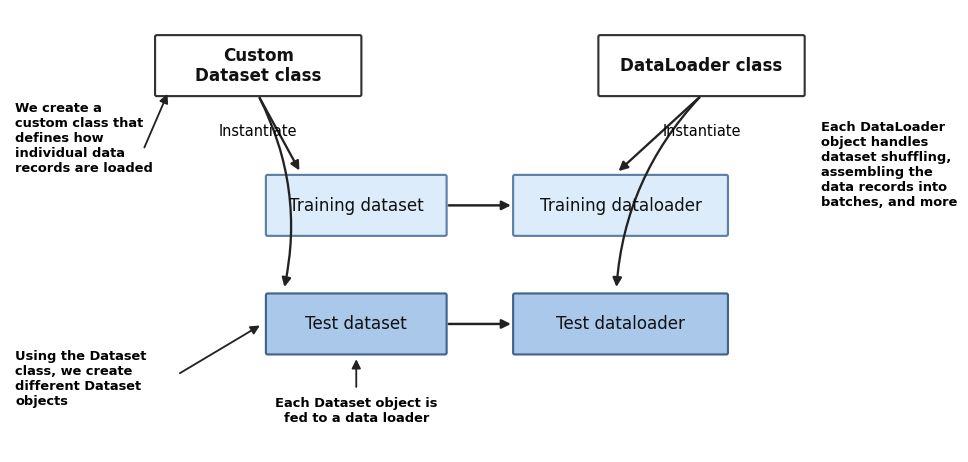
</div>

<div align="center"><i>Source (Sebastian Raschka, Build a Large Language Model From Scratch).</i></div>

### Why the DataLoader does this
* **Batching** so that data is processed in chunks. This ensures memory stays bounded and the hardware can parallelize. Each batch is one gradient update.
* **Shuffling** so that re-ordering is done at every epoch. This also helps mitigate class imbalance that can occur in one batch when all instances in that batch belong to a single class.
* **Efficient loading** by use of worker subprocesses so the GPU isn't left waiting for the next batch.

# 2 - A custom `Dataset` (and where transforms live)

In [9]:
import torch
import torchvision
import numpy as np
from torch.utils.data import Dataset, DataLoader, Sampler

torch.manual_seed(123)  # reproducible shuffling / augmentation

In [10]:
# Training set with two features each
X_train = torch.tensor([[1.0,  2.0],
                        [3.0,  4.0],
                        [5.0,  6.0],
                        [7.0, -8.0],
                        [5.7,  2.5]])
y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([[ 9.0, 10.0],
                       [11.0, 12.0]])
y_test = torch.tensor([0, 1])

In [11]:
class SimpleDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.features = X
        self.labels = y
        self.transform = transform      # <-- transforms/augmentation plug in HERE

    def __getitem__(self, index):
        x = self.features[index]
        if self.transform:
            x = self.transform(x)        # applied per-sample, every time it is fetched
        return x, self.labels[index]

    def __len__(self):
        return self.labels.shape[0]

train_ds = SimpleDataset(X_train, y_train)
test_ds  = SimpleDataset(X_test,  y_test)
print('length of train_ds:', len(train_ds))
print('sample #2:', train_ds[2])

length of train_ds: 5
sample #2: (tensor([5., 6.]), tensor(0))


Three required pieces of a `Dataset`:

* **`__init__`** — set up tensors / file paths / filenames, **and store the `transform`** to apply.
* **`__getitem__`** — return exactly **one** sample; this is where any transform is applied.
* **`__len__`** — return the number of samples.

Notice the `transform` slot. That is the single most important idea for the rest of this notebook: **augmentation is not a separate stage — it is work the `Dataset` does inside `__getitem__` while the `DataLoader` is loading.**

# 3 - Instantiating a `DataLoader`

In [ ]:
train_loader = DataLoader(dataset=train_ds,
                          batch_size=2,
                          shuffle=True,
                          num_workers=0,
                          drop_last=True)

test_loader = DataLoader(dataset=test_ds,
                         batch_size=2,
                         shuffle=False,   # never shuffle test/val data
                         num_workers=0)

In [12]:
for idx, (x, y) in enumerate(train_loader):
    print(f'Batch {idx + 1}:  x = {x.tolist()},  y = {y.tolist()}')

Batch 1:  x = [[7.0, -8.0], [3.0, 4.0]],  y = [1, 0]
Batch 2:  x = [[1.0, 2.0], [5.0, 6.0]],  y = [0, 0]


**Epoch** — one full pass over the training set (the loop above).

**Batch & `batch_size`** — a batch is a group of examples; `batch_size` is how many. Number of iterations = number of batches. With 100 examples and `batch_size=20`, one epoch = 5 iterations.

**`drop_last`** — we have 5 examples with `batch_size=2`, so the leftover example would form a tiny batch of 1. A batch much smaller than the rest can destabilize training, so `drop_last=True` drops it — which is why you saw only 2 full batches.

**`shuffle`** — because we seeded the RNG, iterating again gives a *different* order. Reshuffling each epoch stops the network memorizing order. Use `shuffle=True` for train, `False` for val/test.

# 4 - On-the-fly loading with transforms


You usually can't fit an image dataset in memory, so you read and process each image **only when it is requested**, inside `__getitem__`. This is *lazy* / on-the-fly loading — and it is exactly where transforms (including augmentation, if any) run.

The `Dataset` stores a `transform` and applies it inside `__getitem__`. For symbolism, note that any transform — plumbing or augmentation — slots into the same `transform` parameter, keeping the rest of the pipeline identical.


In [13]:
import os
from PIL import Image
import torchvision.transforms as T

class LargeImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_files = os.listdir(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')   # read from disk on demand
        if self.transform:
            image = self.transform(image)             # resize / augment / to-tensor here
        return image

Because `__getitem__` is called fresh for every sample in every epoch, any *random* transform produces a **new variant each epoch**. Augmentation (random flips, crops, colour jitter, etc.) is simply a subset of transforms — we will not go into the details here, but the key point is that it plugs into the same `transform` argument in your `Dataset`.


Now plug a deterministic transform into a `Dataset` and let the `DataLoader` batch the results. We generate toy images so the cell runs anywhere; in practice you'd read them from disk as in Section 4.


In [20]:
from PIL import Image, ImageDraw
import torchvision.transforms as T

def make_toy_image(color, size=224):
    img = Image.new('RGB', (size, size), (235, 240, 250))
    ImageDraw.Draw(img).rectangle([size*0.3, size*0.3, size*0.7, size*0.7], fill=color)
    return img

class ToyImageDataset(Dataset):
    def __init__(self, n=8, transform=None):
        colors = [(200,50,50),(50,200,50),(50,50,200),(200,200,50),
                  (50,200,200),(200,50,200),(150,100,50),(100,150,200)]
        self.images = [make_toy_image(colors[i % len(colors)]) for i in range(n)]
        self.labels = [i % 4 for i in range(n)]
        self.transform = transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# Symbolic: transform=T.ToTensor() converts PIL images to tensors.
# Augmentation would plug in here the same way.
toy_transform = T.Compose([T.ToTensor()])
toy_ds = ToyImageDataset(n=8, transform=toy_transform)
toy_loader = DataLoader(toy_ds, batch_size=4, shuffle=True)

for batch_imgs, batch_labels in toy_loader:
    print(f"Batch shape: {batch_imgs.shape},  labels: {batch_labels.tolist()}")


Batch shape: torch.Size([4, 3, 224, 224]),  labels: [1, 2, 0, 3]
Batch shape: torch.Size([4, 3, 224, 224]),  labels: [0, 1, 2, 3]


# 5 - `Sampler` and `BatchSampler`


How does the `DataLoader` decide **which** indices go into each batch, and in what order? That job belongs to a **`Sampler`**.

* `shuffle=False` → **`SequentialSampler`** (indices `0,1,2,...`).
* `shuffle=True`  → **`RandomSampler`** (a random permutation each epoch).
* A **`BatchSampler`** wraps a sampler and groups its indices into batches.

When you pass `shuffle=True`, the DataLoader is really just picking a sampler for you. Writing a **custom sampler** gives you full control — e.g. class-balanced batches for imbalanced data, or weighted / stratified sampling.

<div style="text-align:center">
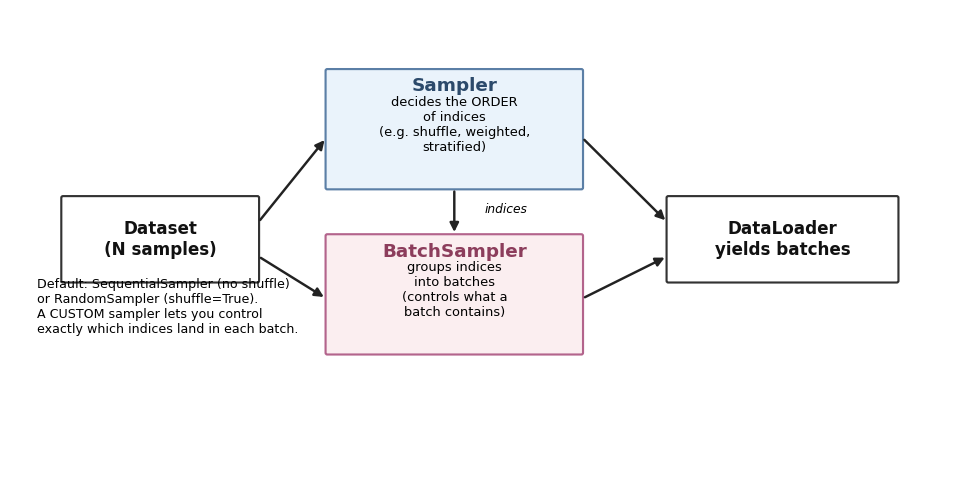
</div>

A custom sampler implements `__iter__` (yields the indices for one batch) and `__len__` (number of batches). Below, a balanced sampler that puts an equal number of even and odd numbers in every batch:

In [26]:
class EvenOddDataset(Dataset):
    def __init__(self, start, end):
        self.numbers = list(range(start, end))
    def __len__(self):
        return len(self.numbers)
    def __getitem__(self, idx):
        n = self.numbers[idx]
        label = 1 if n % 2 else 0        # 1 = odd, 0 = even
        return n, label

dataset = EvenOddDataset(0, 100)
print('first 5 samples:', [dataset[i] for i in range(5)])

first 5 samples: [(0, 0), (1, 1), (2, 0), (3, 1), (4, 0)]


In [27]:
class BalancedBatchSampler(Sampler):
    def __init__(self, dataset, batch_size):
        self.batch_size = batch_size
        labels = [label for _, label in dataset]
        self.class_indices = {}
        for idx, lab in enumerate(labels):
            self.class_indices.setdefault(lab, []).append(idx)
        self.num_batches = int(np.ceil(len(dataset) / batch_size))

    def __iter__(self):
        per_class = self.batch_size // len(self.class_indices)
        for _ in range(self.num_batches):
            batch = []
            for idxs in self.class_indices.values():
                batch.extend(np.random.choice(idxs, per_class, replace=False))
            np.random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches

sampler = BalancedBatchSampler(dataset, batch_size=8)
loader  = DataLoader(dataset, batch_sampler=sampler)   # note: batch_sampler=, not batch_size=

nums, labels = next(iter(loader))
print('one balanced batch — numbers:', nums.tolist())
print('one balanced batch — labels :', labels.tolist(), '(equal 0s and 1s)')

one balanced batch — numbers: [19, 34, 24, 52, 11, 49, 81, 74]
one balanced batch — labels : [1, 0, 0, 0, 1, 1, 1, 0] (equal 0s and 1s)


> When you pass a `batch_sampler`, you must **not** also pass `batch_size`, `shuffle`, or `drop_last` — the sampler already decides all of that.

# 6 - `collate_fn`


The `collate_fn` controls **how a list of samples becomes a batch**. The default stacks samples into a tensor; a custom one lets you do batch-level work — normalize using batch stats, or **pad variable-length sequences** to equal length (very common in NLP/speech). Since it can run inside worker processes, it is parallelized too.

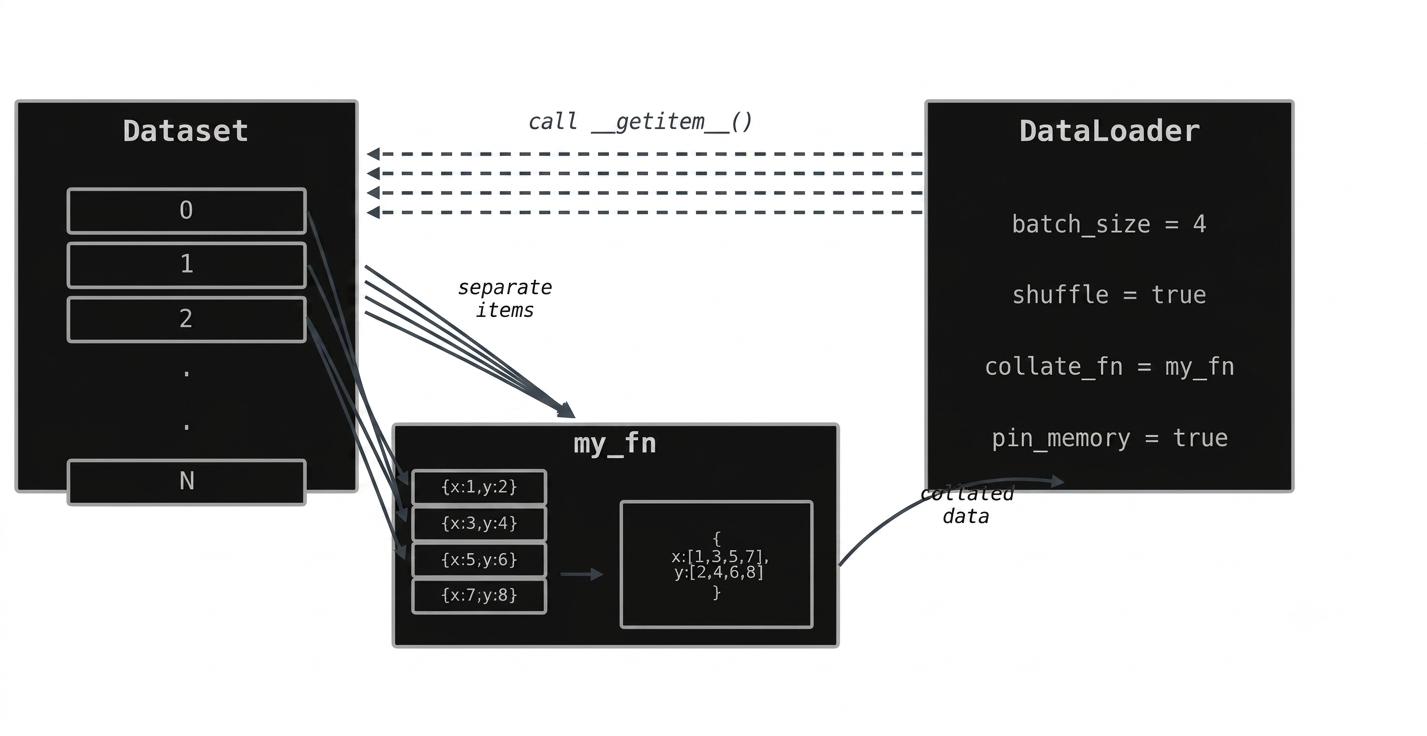

<div align="center"><i>Source (Luke Salamone, Custom PyTorch Collate Function).</i></div>

In [29]:
class MyNormalDataset(Dataset):
    def __init__(self, xs, ys):
        self.input, self.target = xs, ys
    def __len__(self):
        return len(self.input)
    def __getitem__(self, i):
        return self.input[i], self.target[i]

    def collate_fn(self, batch):
        x, y = zip(*batch)                       # list of (x,y) -> tuples
        x = np.array(x, dtype=np.float32)
        x_norm = (x - x.mean()) / (x.std() + 1e-9)
        return torch.tensor(x_norm), torch.tensor(y)

dataset = MyNormalDataset(np.arange(10), np.arange(0, 20, 2))
loader = DataLoader(dataset, batch_size=5, shuffle=True, collate_fn=dataset.collate_fn)
for i, (x, y) in enumerate(loader):
    print(f'Batch {i+1}: normalized x = {x.numpy().round(2)}, y = {y.numpy()}')

Batch 1: normalized x = [ 0.77  1.15  0.38 -1.53 -0.77], y = [14 16 12  2  6]
Batch 2: normalized x = [ 1.65  0.   -0.66  0.33 -1.32], y = [18  8  4 10  0]


# 7 - `num_workers` and `pin_memory`


### `num_workers`
`num_workers` sets how many background **subprocesses** load and preprocess data.

* `num_workers=0` → loading happens in the **main** process; the GPU sits idle while the next batch (including its augmentation) is prepared.
* `num_workers>0` → workers **prefetch** upcoming batches while the GPU trains, so the GPU rarely waits.

<div style="text-align: center;">
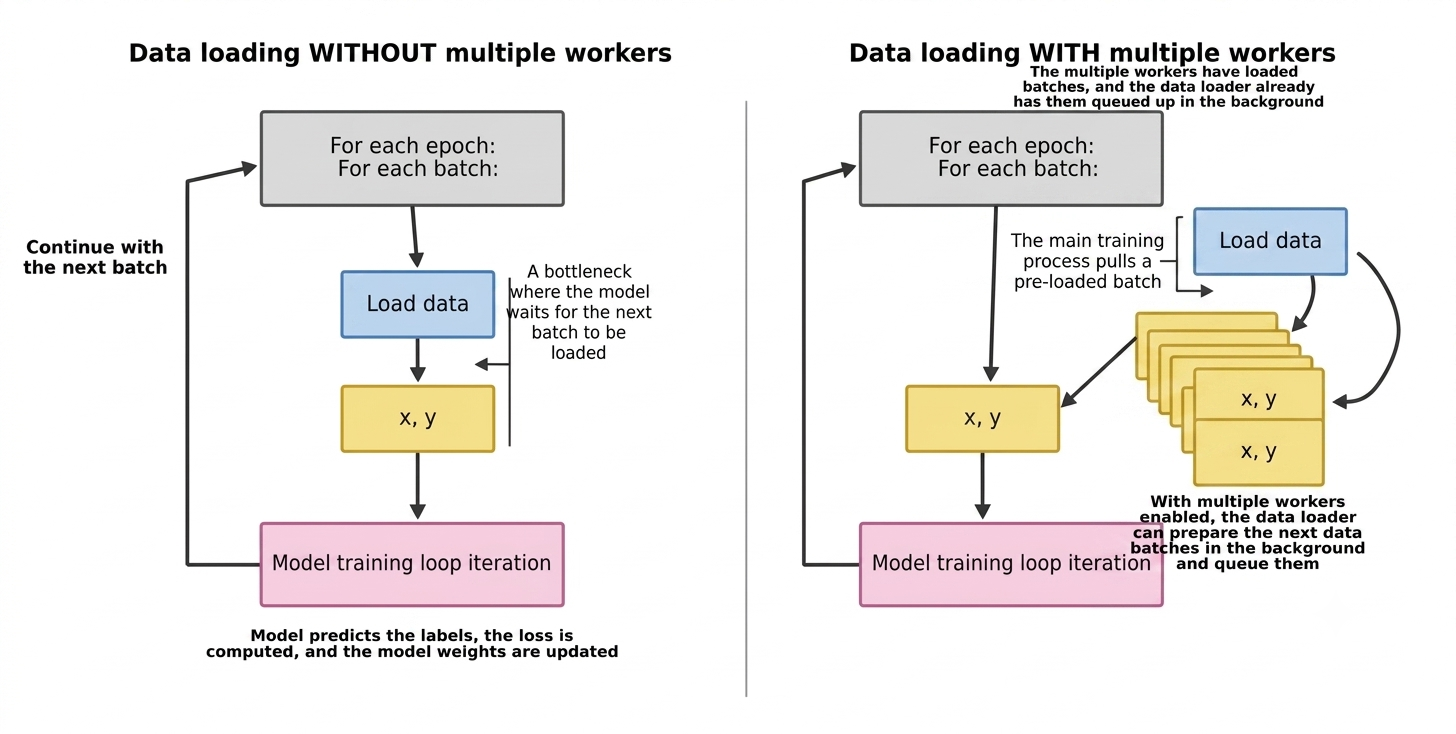
</div>

<div align="center"><i>Source (Sebastian Raschka, Build a Large Language Model From Scratch).</i></div>

This matters most when `__getitem__` is expensive — reading an image from disk **and augmenting it**. For tiny in-memory datasets it makes no measurable difference.

In [32]:
# more workers prefetch in the background
loader_fast = DataLoader(dataset, batch_size=5, shuffle=True,
                         collate_fn=dataset.collate_fn, num_workers=2)

### `pin_memory`
`pin_memory=True` stages tensors in **page-locked (pinned)** host memory, which makes the CPU→GPU copy faster. Recommended when training on a GPU.

<div style="text-align:center">
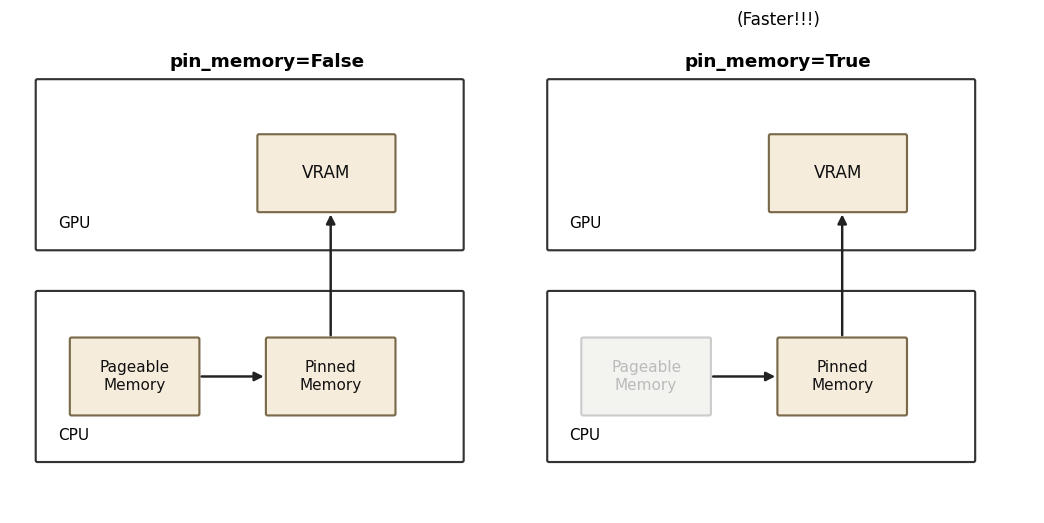
</div>

<div align="center"><i>Source (Srishti Gureja, How to Create a Dataloader in PyTorch?).</i></div>

In [33]:
loader_faster = DataLoader(dataset, batch_size=5, shuffle=True,
                           collate_fn=dataset.collate_fn,
                           num_workers=2, pin_memory=True)

The best `num_workers` depends on the machine (CPU cores, disk speed). Start near the number of cores and increase until you stop seeing a speedup or hit a warning.

# 8 - Your turn: hands-on exercises


Fill in the `# TODO` blocks. Solutions are in a collapsible block at the bottom — try each first!

### Exercise 1 — Which augmentations are *safe* for MNIST?
MNIST is 28×28 grayscale digits (0–9). Some transforms **break the label** (flipping `6`→`9`; big rotations). Decide which are safe, then build a safe train pipeline and a deterministic test pipeline.

| Transform | Safe for MNIST? |
|---|---|
| `RandomHorizontalFlip` | ? |
| `RandomVerticalFlip` | ? |
| `RandomRotation(10)` | ? |
| `RandomRotation(180)` | ? |
| `RandomAffine(translate=...)` | ? |
| `Normalize` | ? |

In [ ]:
import torchvision.transforms as T

# TODO: build a SAFE MNIST training pipeline.
#   - flips change the digit's identity -> which must you avoid?
#   - small rotations/shifts are fine; large rotations are not.
#   - MNIST is single-channel: Normalize with ONE mean and ONE std (~0.1307 / 0.3081).
mnist_train_transform = T.Compose([
    # TODO: 1-3 label-preserving augmentations
    T.ToTensor(),
    # TODO: Normalize (single channel)
])

# TODO: TEST transform must be DETERMINISTIC (no random augments), same Normalize.
mnist_test_transform = T.Compose([
    T.ToTensor(),
    # TODO: Normalize
])
print(mnist_train_transform)

### Exercise 2 — Complete the custom `Dataset`

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class DigitDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images        # list of 28x28 uint8 arrays
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # TODO: number of samples
        pass

    def __getitem__(self, idx):
        # TODO: (1) idx-th array -> PIL Image (mode 'L'); (2) apply transform if set; (3) return (img, label)
        pass

fake_imgs = [np.random.randint(0, 256, (28, 28), dtype=np.uint8) for _ in range(8)]
fake_lbls = list(range(8))
# ds = DigitDataset(fake_imgs, fake_lbls, transform=mnist_train_transform)
# print(len(ds)); x, y = ds[0]; print(x.shape, y)   # expect torch.Size([1,28,28])

### Exercise 3 — Configure the loaders (right settings per split)

In [ ]:
from torch.utils.data import DataLoader

# train_ds = DigitDataset(fake_imgs, fake_lbls, transform=mnist_train_transform)
# test_ds  = DigitDataset(fake_imgs, fake_lbls, transform=mnist_test_transform)

# TODO train_loader: batch_size=4, shuffle appropriately, drop the last partial batch
# TODO test_loader : batch_size=4, NO shuffle, NO drop_last

### Exercise 4 — Brain teasers
1. You set `num_workers=8` but training gets **slower**. Two possible reasons?
2. Validation accuracy is noisy with fixed weights. What did you forget?
3. Is `RandomHorizontalFlip` safe for cat-vs-dog photos? For traffic signs ('turn left' vs 'turn right')?
4. `RandomResizedCrop(scale=(0.05, 1.0))` — why might such an aggressive lower bound hurt training?
5. You pass a custom `batch_sampler` **and** `shuffle=True`. What happens?

---

# Recap / Cheat-sheet

| Concept | What it does | Rule of thumb |
|---|---|---|
| `batch_size` | # samples per pass | Bigger = more memory, smoother gradients |
| `shuffle` | reorders each epoch | `True` train, `False` val/test |
| `drop_last` | drops final partial batch | `True` if a tiny last batch hurts |
| `Sampler` | picks index order | custom = balanced/weighted batches |
| `collate_fn` | list of samples -> batch | pad sequences / batch-level transforms |
| `num_workers` | parallel loading | >0 when loading+augmenting is expensive |
| `pin_memory` | page-locked host memory | `True` on GPU |
| **transforms/augmentation** | per-sample work in `__getitem__` | random ones = **train only** |

**Most common mistakes:** augmenting or shuffling the test set; label-breaking augmentations (flipping digits); different normalization for train vs test.